In [1]:
import numpy as np
import os
import pandas as pd
import random
import json
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

In [ ]:
results_dir = ["/capstor/scratch/cscs/framunno/results_diffusion_COND_CLASSIC_AR50_step200k_dynamics25_v2_high_activity_filter", "/capstor/scratch/cscs/framunno/results_diffusion_NOCOND_AR50_step200k_dynamics25_v2_high_activity_filter",
"/capstor/scratch/cscs/framunno/results_unet_AR50_step200k_dynamics25_v2_high_activity_filter"]

#results_dir = ["/capstor/scratch/cscs/framunno/results_diffusion_classic_AR50_step200k_dynamics75_v2", "/capstor/scratch/cscs/framunno/results_diffusion_NOCOND_AR50_step200k_dynamics75_v2",
#"/capstor/scratch/cscs/framunno/results_unet_AR50_step200k_dynamics75_v2"]

#results_dir = ["/capstor/scratch/cscs/framunno/results_diffusion_COND_CLASSIC_AR50_step200k_dynamics75_v2_high_activity_filter", "/capstor/scratch/cscs/framunno/results_diffusion_NOCOND_AR50_step200k_dynamics75_v2_high_activity_filter",
#"/capstor/scratch/cscs/framunno/results_unet_AR50_step200k_dynamics75_v2_high_activity_filter"]

gt_dir  = os.path.join(results_dir[0], 'ground_truth')

gen_dir = []
meta_dir = []

for res_dir in results_dir:
    gen_dir.append(os.path.join(res_dir, 'generated_imgs'))
    meta_dir.append(os.path.join(res_dir, 'metadata'))

In [13]:
gen_dir

['/capstor/scratch/cscs/framunno/results_diffusion_classic_AR50_step200k/generated_imgs',
 '/capstor/scratch/cscs/framunno/results_diffusion_nocond_AR50_step200k/generated_imgs',
 '/capstor/scratch/cscs/framunno/results_unet_AR50_step200k/generated_imgs']

In [16]:
meta

{'center_idx': 1145155,
 'center_time': '2024-10-04 10:46:00',
 'start_time': '2024-10-04 09:56:00',
 'end_time': '2024-10-04 11:34:00',
 'sample_idx': 0,
 'model_type': 'diffusion',
 'autoregressive': True,
 'n_rollout_steps': 5}

In [3]:
from tqdm import tqdm

pred_models = {
    "diffusion_classic": [],
    "diffusion_nocond": [],
    "unet": []
}

labels = ["diffusion_classic", "diffusion_nocond", "unet"]

gt_images = []

start_time = []
end_time = []

for gen, meta, label in zip(gen_dir, meta_dir, labels):
    print(f"Generated images directory: {gen}")
    print(f"Metadata directory: {meta}")
    indices = sorted(
        int(f.split('_')[1].split('.')[0])
        for f in os.listdir(gen)
        if f.startswith('pred_') and f.endswith('.npy')
    )

    records = []
    for k in tqdm(indices, desc=label):
        pred_path   = os.path.join(gen,  f'pred_{k}.npy')
        target_path = os.path.join(gt_dir,   f'target_{k}.npy')
        meta_path   = os.path.join(meta, f'meta_{k}.json')

        if not os.path.exists(target_path):
            continue

        pred   = np.load(pred_path).astype(np.float32)   # (n_samples, T, H, W)
        target = np.load(target_path).astype(np.float32) # (T, H, W)

        gt_images.append(target)
        pred_models[label].append(pred)

        n_samples, T, H, W = pred.shape

        meta_time = {}
        if os.path.exists(meta_path):
            with open(meta_path) as f:
                meta_time = json.load(f)
        start_time.append(meta_time.get('start_time', 0))
        end_time.append(meta_time.get('end_time', 0))

Generated images directory: /capstor/scratch/cscs/framunno/results_diffusion_COND_CLASSIC_AR50_step200k_dynamics25_v2_high_activity_filter/generated_imgs
Metadata directory: /capstor/scratch/cscs/framunno/results_diffusion_COND_CLASSIC_AR50_step200k_dynamics25_v2_high_activity_filter/metadata


diffusion_classic: 100%|██████████| 389/389 [00:53<00:00,  7.25it/s]


Generated images directory: /capstor/scratch/cscs/framunno/results_diffusion_NOCOND_AR50_step200k_dynamics25_v2_high_activity_filter/generated_imgs
Metadata directory: /capstor/scratch/cscs/framunno/results_diffusion_NOCOND_AR50_step200k_dynamics25_v2_high_activity_filter/metadata


diffusion_nocond: 100%|██████████| 389/389 [00:50<00:00,  7.78it/s]


Generated images directory: /capstor/scratch/cscs/framunno/results_unet_AR50_step200k_dynamics25_v2_high_activity_filter/generated_imgs
Metadata directory: /capstor/scratch/cscs/framunno/results_unet_AR50_step200k_dynamics25_v2_high_activity_filter/metadata


unet: 100%|██████████| 389/389 [00:34<00:00, 11.14it/s]


In [4]:
len(pred_models['diffusion_classic']), len(pred_models['diffusion_nocond']), len(pred_models['unet'])

(389, 389, 389)

In [5]:
gt_images_concat = np.array(gt_images[:389]) # (n_samples, T, H, W)
gt_images_concat.shape

diff_cond = np.array(pred_models['diffusion_classic'][:389]).mean(axis=1) # (n_samples, H, W)
diff_nocond = np.array(pred_models['diffusion_nocond'][:389]).mean(axis=1) # (n_samples, H, W)
unet_pred = np.array(pred_models['unet'][:389]).mean(axis=1) # (n_samples, H, W)

In [6]:
PHYS_MIN_V, PHYS_MAX_V = -80000.0, 80000.0
def unnorm_v(x):                                                                                                                                                            
    return ((x + 1) / 2) * (PHYS_MAX_V - PHYS_MIN_V) + PHYS_MIN_V     

gt_average        = np.mean(unnorm_v(gt_images_concat), axis=(-1, -2))   # (101, 35) in Volts
diff_cond_average = np.mean(unnorm_v(diff_cond),        axis=(-1, -2))
diff_nocond_average = np.mean(unnorm_v(diff_nocond),    axis=(-1, -2))
unet_pred_average = np.mean(unnorm_v(unet_pred),        axis=(-1, -2))

In [38]:
gt_average.shape, diff_cond_average.shape, diff_nocond_average.shape, unet_pred_average.shape

((101, 35), (101, 35), (101, 35), (101, 35))

In [17]:
diff_cond_average[:-1].shape

(62, 35)

In [7]:
gt_pct = np.diff(gt_average, axis=1) / gt_average[:, :-1]
gt_pct = gt_pct * 100
gt_pct = np.concatenate(
    [np.zeros((gt_average.shape[0], 1)), gt_pct],
    axis=1
)

diff_cond_pct = np.diff(diff_cond_average) / diff_cond_average[:, :-1]
diff_cond_pct = diff_cond_pct * 100
diff_cond_pct = np.concatenate(
    [np.zeros((gt_average.shape[0], 1)), diff_cond_pct],
    axis=1
)


diff_nocond_pct = np.diff(diff_nocond_average) / diff_nocond_average[:, :-1]
diff_nocond_pct = diff_nocond_pct * 100
diff_nocond_pct = np.concatenate(
    [np.zeros((gt_average.shape[0], 1)), diff_nocond_pct],
    axis=1
)

unet_pred_pct = np.diff(unet_pred_average) / unet_pred_average[:, :-1]
unet_pred_pct = unet_pred_pct * 100
unet_pred_pct = np.concatenate(
    [np.zeros((gt_average.shape[0], 1)), unet_pred_pct],
    axis=1
)

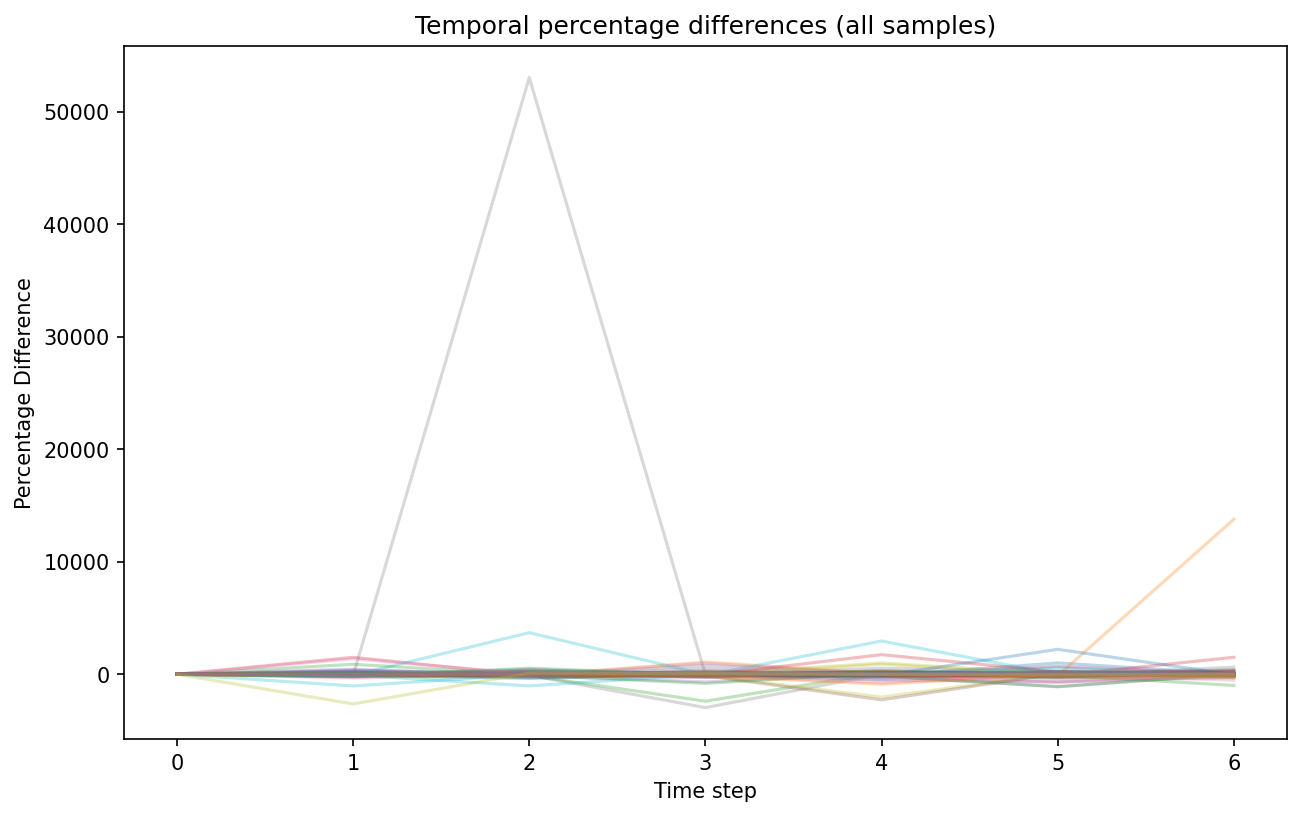

In [10]:
from PIL import Image

# x-axis: time steps (0..33)
x = np.arange(gt_pct.shape[1])

plt.figure(figsize=(10, 6))

# plot each sample
for i in range(gt_pct.shape[0]):
    plt.plot(x, gt_pct[i], alpha=0.3)  # low alpha to avoid clutter

plt.xlabel("Time step")
plt.ylabel("Percentage Difference")
plt.title("Temporal percentage differences (all samples)")

# save figure
save_path = "/users/framunno/visual_res/gt_pct_plot.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.close()  # close to free memory

Image.open(save_path)

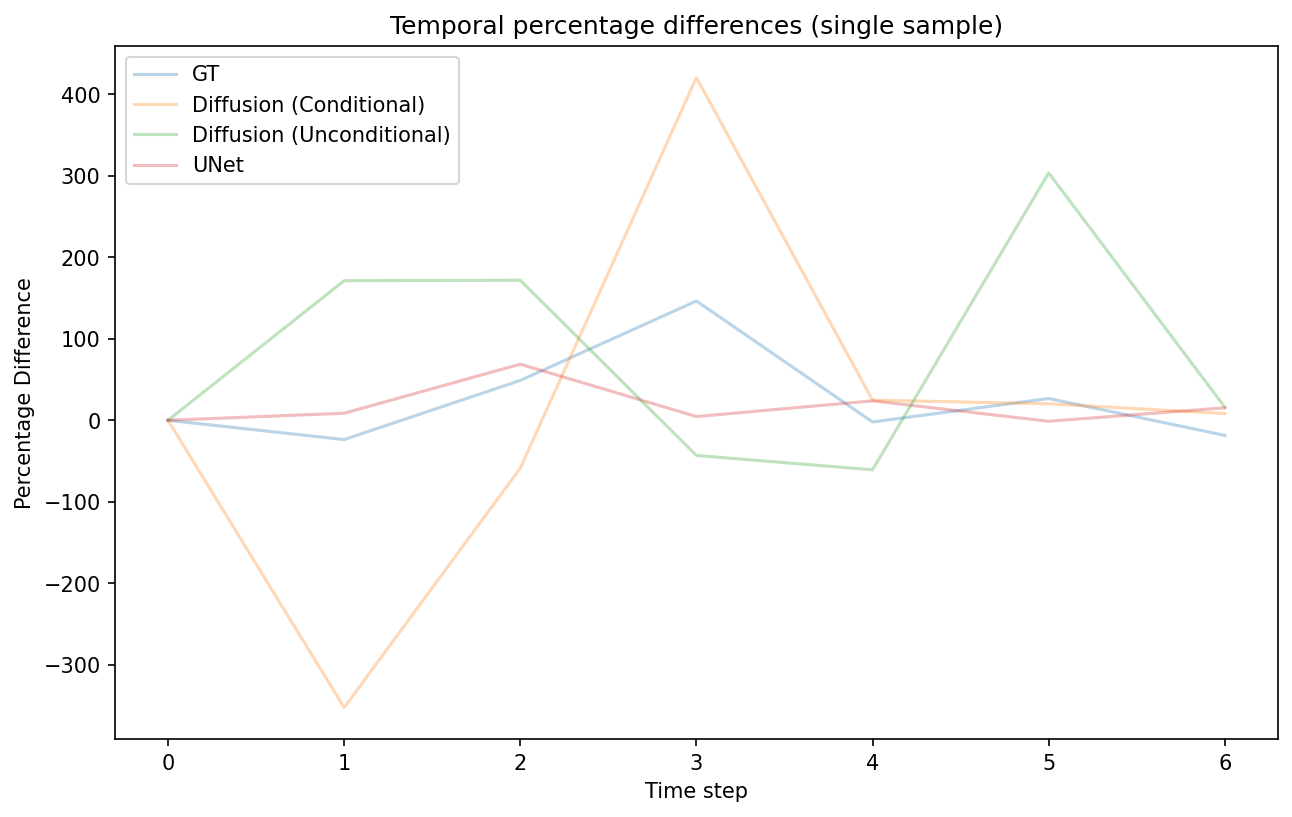

In [11]:
import random

# x-axis: time steps (0..33)
x = np.arange(gt_pct.shape[1])

plt.figure(figsize=(10, 6))

# plot each sample
i = random.randint(0, gt_pct.shape[0] - 1)
plt.plot(x, gt_pct[i], alpha=0.3, label="GT")  # low alpha to avoid clutter
plt.plot(x, diff_cond_pct[i], alpha=0.3, label="Diffusion (Conditional)")
plt.plot(x, diff_nocond_pct[i], alpha=0.3, label="Diffusion (Unconditional)")
plt.plot(x, unet_pred_pct[i], alpha=0.3, label="UNet")

plt.xlabel("Time step")
plt.ylabel("Percentage Difference")
plt.title("Temporal percentage differences (single sample)")
plt.legend()

# save figure
save_path = "/users/framunno/visual_res/gt_pct_plot_single.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.close()  # close to free memory

Image.open(save_path)

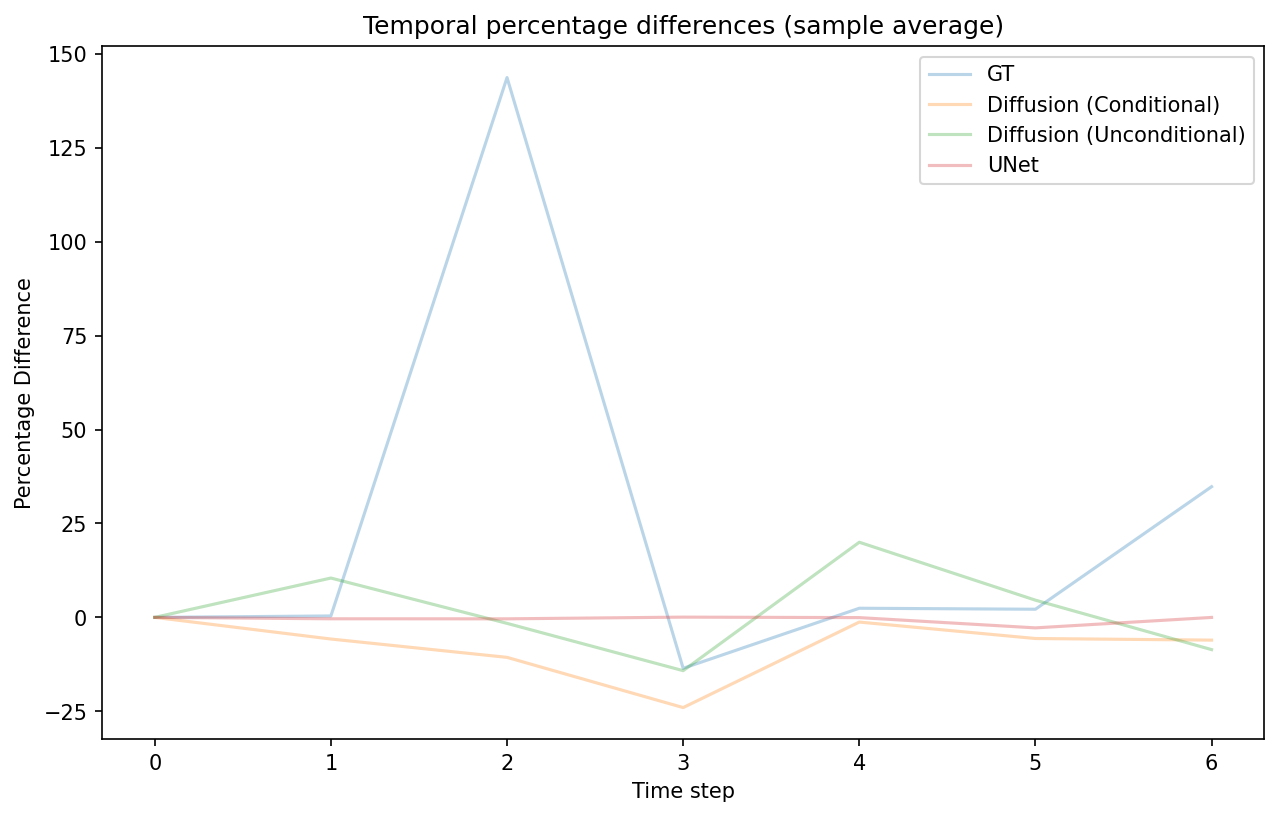

In [12]:
import random

# x-axis: time steps (0..33)
x = np.arange(gt_pct.shape[1])

plt.figure(figsize=(10, 6))

# plot each sample
plt.plot(x, np.mean(gt_pct, axis=0), alpha=0.3, label="GT")  # low alpha to avoid clutter
plt.plot(x, np.mean(diff_cond_pct, axis=0), alpha=0.3, label="Diffusion (Conditional)")
plt.plot(x, np.mean(diff_nocond_pct, axis=0), alpha=0.3, label="Diffusion (Unconditional)")
plt.plot(x, np.mean(unet_pred_pct, axis=0), alpha=0.3, label="UNet")
#plt.errorbar(x, np.mean(gt_pct, axis=0), yerr=np.std(gt_pct, axis=0), alpha=0.3)

plt.xlabel("Time step")
plt.ylabel("Percentage Difference")
plt.title("Temporal percentage differences (sample average)")
plt.legend()
# save figure
save_path = "/users/framunno/visual_res/gt_pct_plot_average.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.close()  # close to free memory

Image.open(save_path)

In [13]:
average_time_gt = np.mean(gt_pct, axis=1)
average_time_diff_cond = np.mean(diff_cond_pct, axis=1)
average_time_diff_nocond = np.mean(diff_nocond_pct, axis=1)
average_time_unet = np.mean(unet_pred_pct, axis=1)

average_time_gt.shape, average_time_diff_cond.shape, average_time_diff_nocond.shape, average_time_unet.shape


((389,), (389,), (389,), (389,))

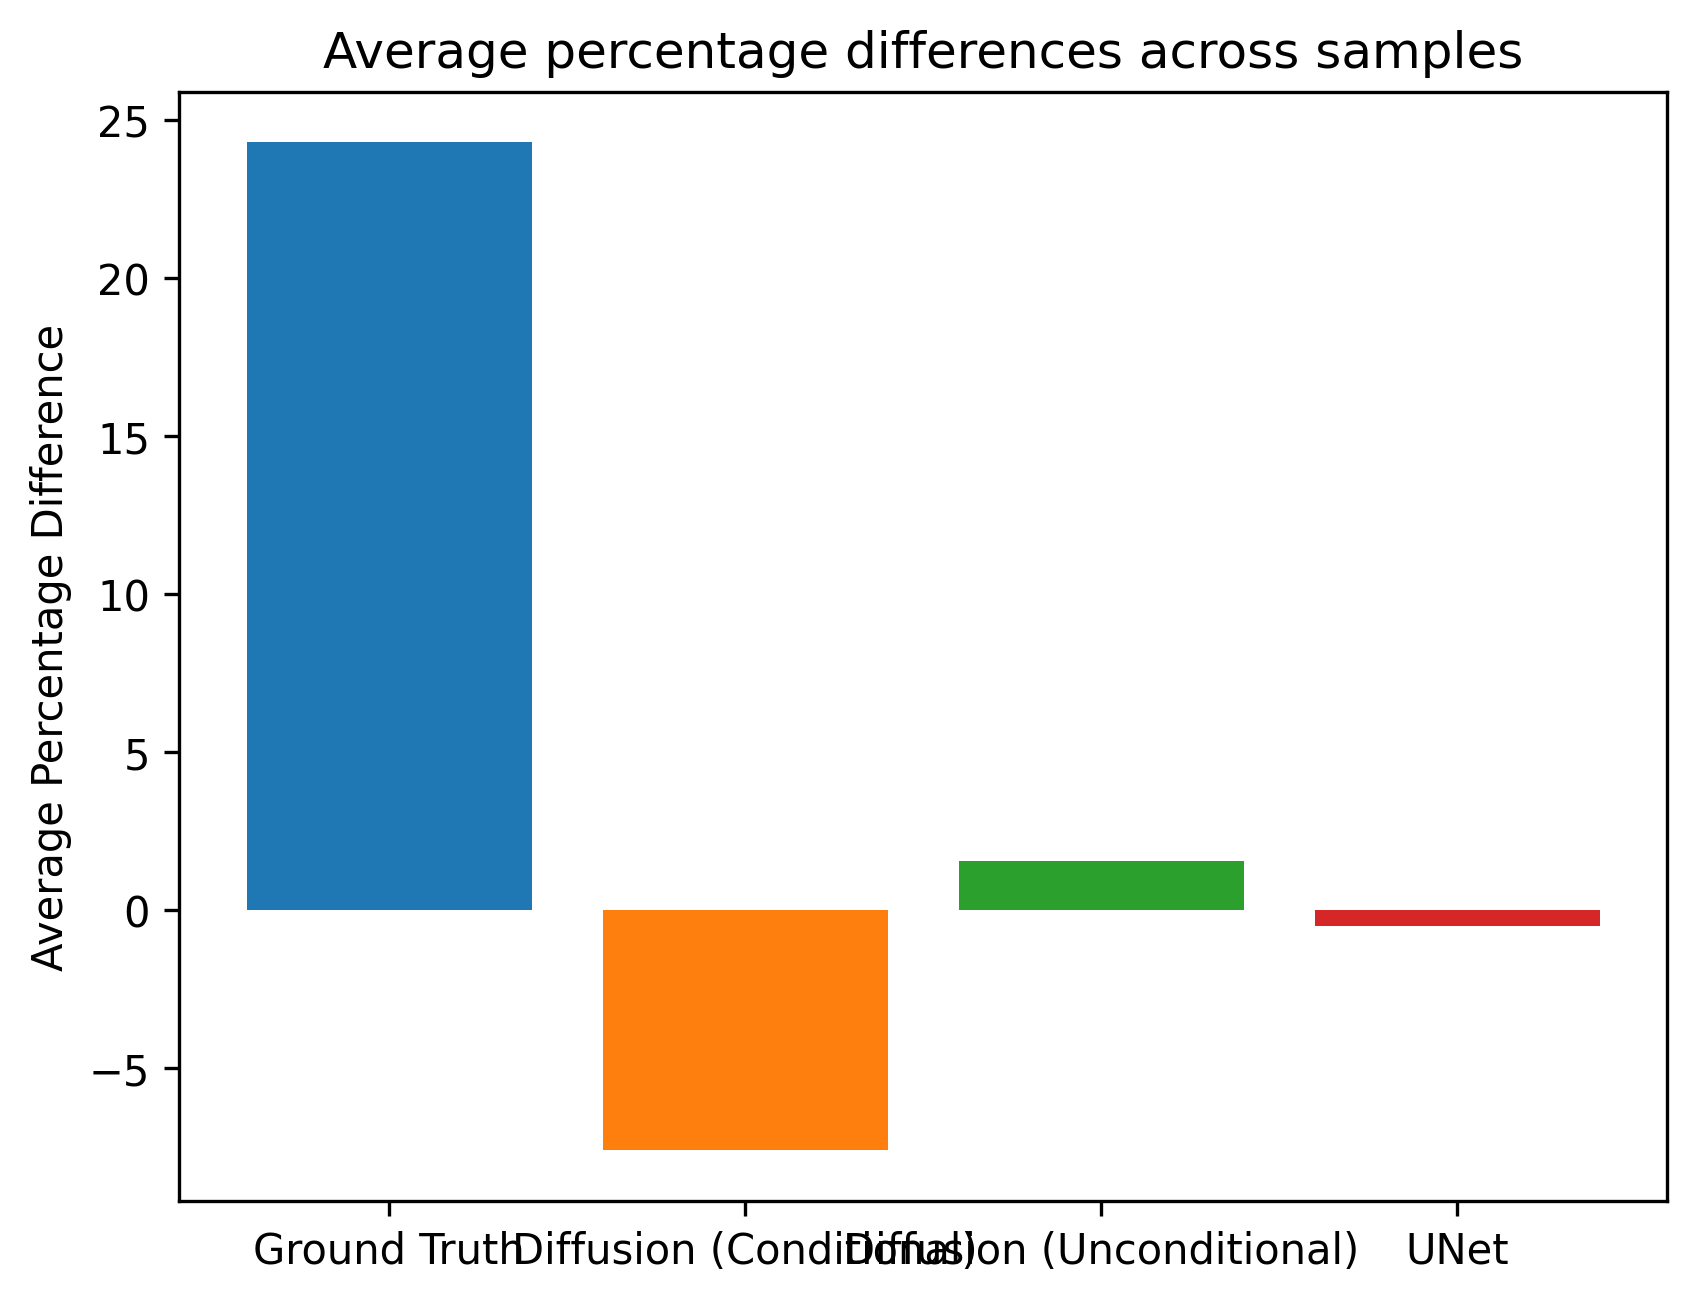

In [14]:
x = ['Ground Truth', 'Diffusion (Conditional)', 'Diffusion (Unconditional)', 'UNet']

plt.bar(x[0], np.mean(average_time_gt), alpha=1)
plt.bar(x[1], np.mean(average_time_diff_cond), alpha=1)
plt.bar(x[2], np.mean(average_time_diff_nocond), alpha=1)
plt.bar(x[3], np.mean(average_time_unet), alpha=1)
plt.ylabel("Average Percentage Difference")
plt.title("Average percentage differences across samples")

save_path = "/users/framunno/visual_res/plot_bar_dyn25_high_activity.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.close()  # close to free memory

Image.open(save_path)

In [45]:
np.mean(average_time_gt), np.mean(average_time_diff_cond), np.mean(average_time_diff_nocond), np.mean(average_time_unet)

(np.float64(0.7149380467422491),
 np.float64(-3.670280832778452),
 np.float64(-67.97965310398344),
 np.float64(141.7481446323615))

In [46]:
np.mean((average_time_gt - average_time_diff_cond) / average_time_gt), np.mean((average_time_gt - average_time_diff_nocond) / average_time_gt), np.mean((average_time_gt - average_time_unet) / average_time_gt)

(np.float64(1.5928418991831648),
 np.float64(0.45367775737543703),
 np.float64(2.7802162914228212))

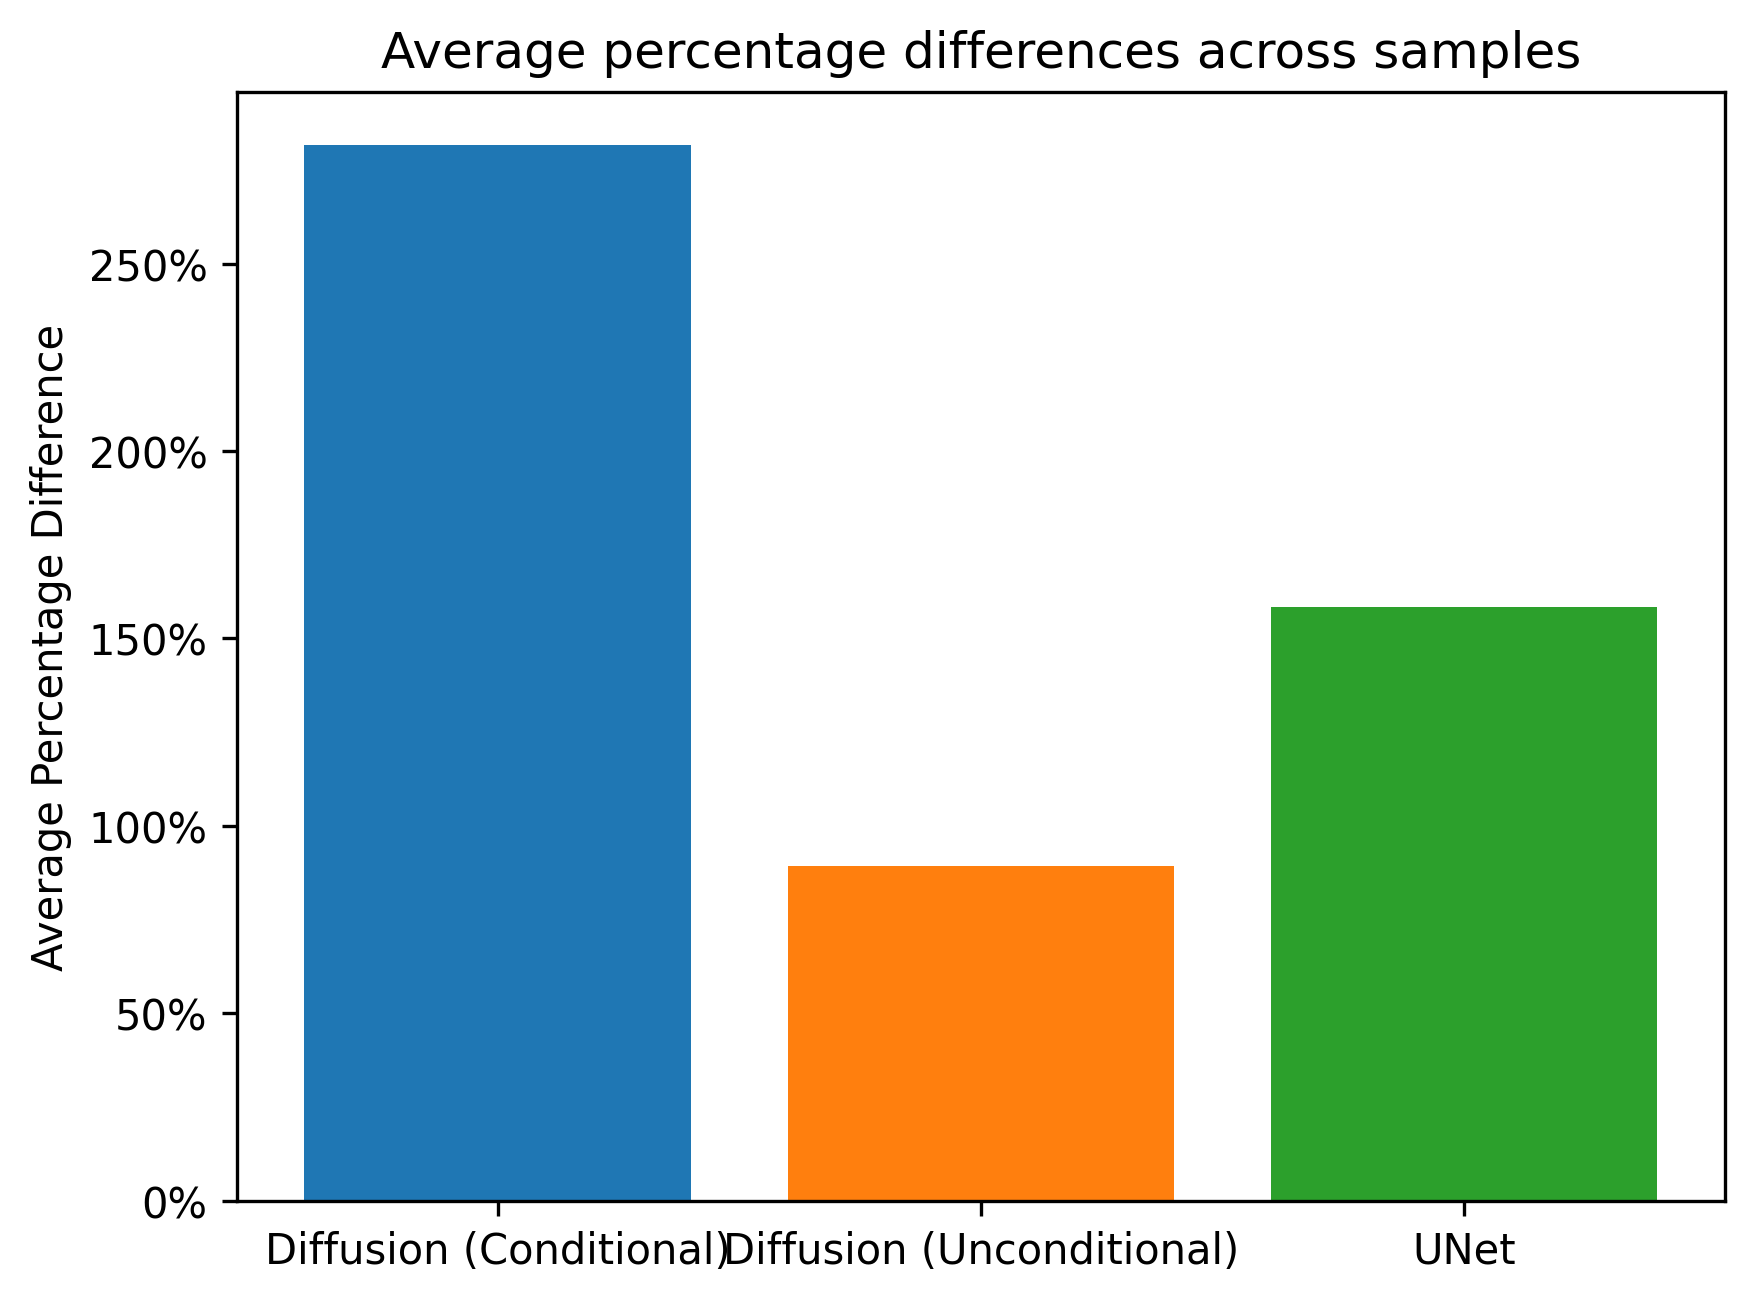

In [15]:
import matplotlib.ticker as mtick

x = ['Diffusion (Conditional)', 'Diffusion (Unconditional)', 'UNet']

plt.bar(x[0], np.mean((average_time_gt - average_time_diff_cond) / average_time_gt), alpha=1)
plt.bar(x[1], np.mean((average_time_gt - average_time_diff_nocond) / average_time_gt), alpha=1)
plt.bar(x[2], np.mean((average_time_gt - average_time_unet) / average_time_gt), alpha=1)
plt.ylabel("Average Percentage Difference")
plt.title("Average percentage differences across samples")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

save_path = "/users/framunno/visual_res/plot_bar_dyn25_high_activity.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.close()  # close to free memory

Image.open(save_path)

In [48]:
zeros = np.zeros((gt_average.shape[0], 1))                                                                                                                                  
                                                                                                                                                                            
gt_pct          = np.concatenate([zeros, np.diff(gt_average,          axis=1) / 1000], axis=1)                                                                              
diff_cond_pct   = np.concatenate([zeros, np.diff(diff_cond_average,   axis=1) / 1000], axis=1)
diff_nocond_pct = np.concatenate([zeros, np.diff(diff_nocond_average, axis=1) / 1000], axis=1)                                                                              
unet_pred_pct   = np.concatenate([zeros, np.diff(unet_pred_average,   axis=1) / 1000], axis=1) 

In [28]:
gt_pct.shape, diff_cond_pct.shape, diff_nocond_pct.shape, unet_pred_pct.shape

((63, 35), (63, 35), (63, 35), (63, 35))

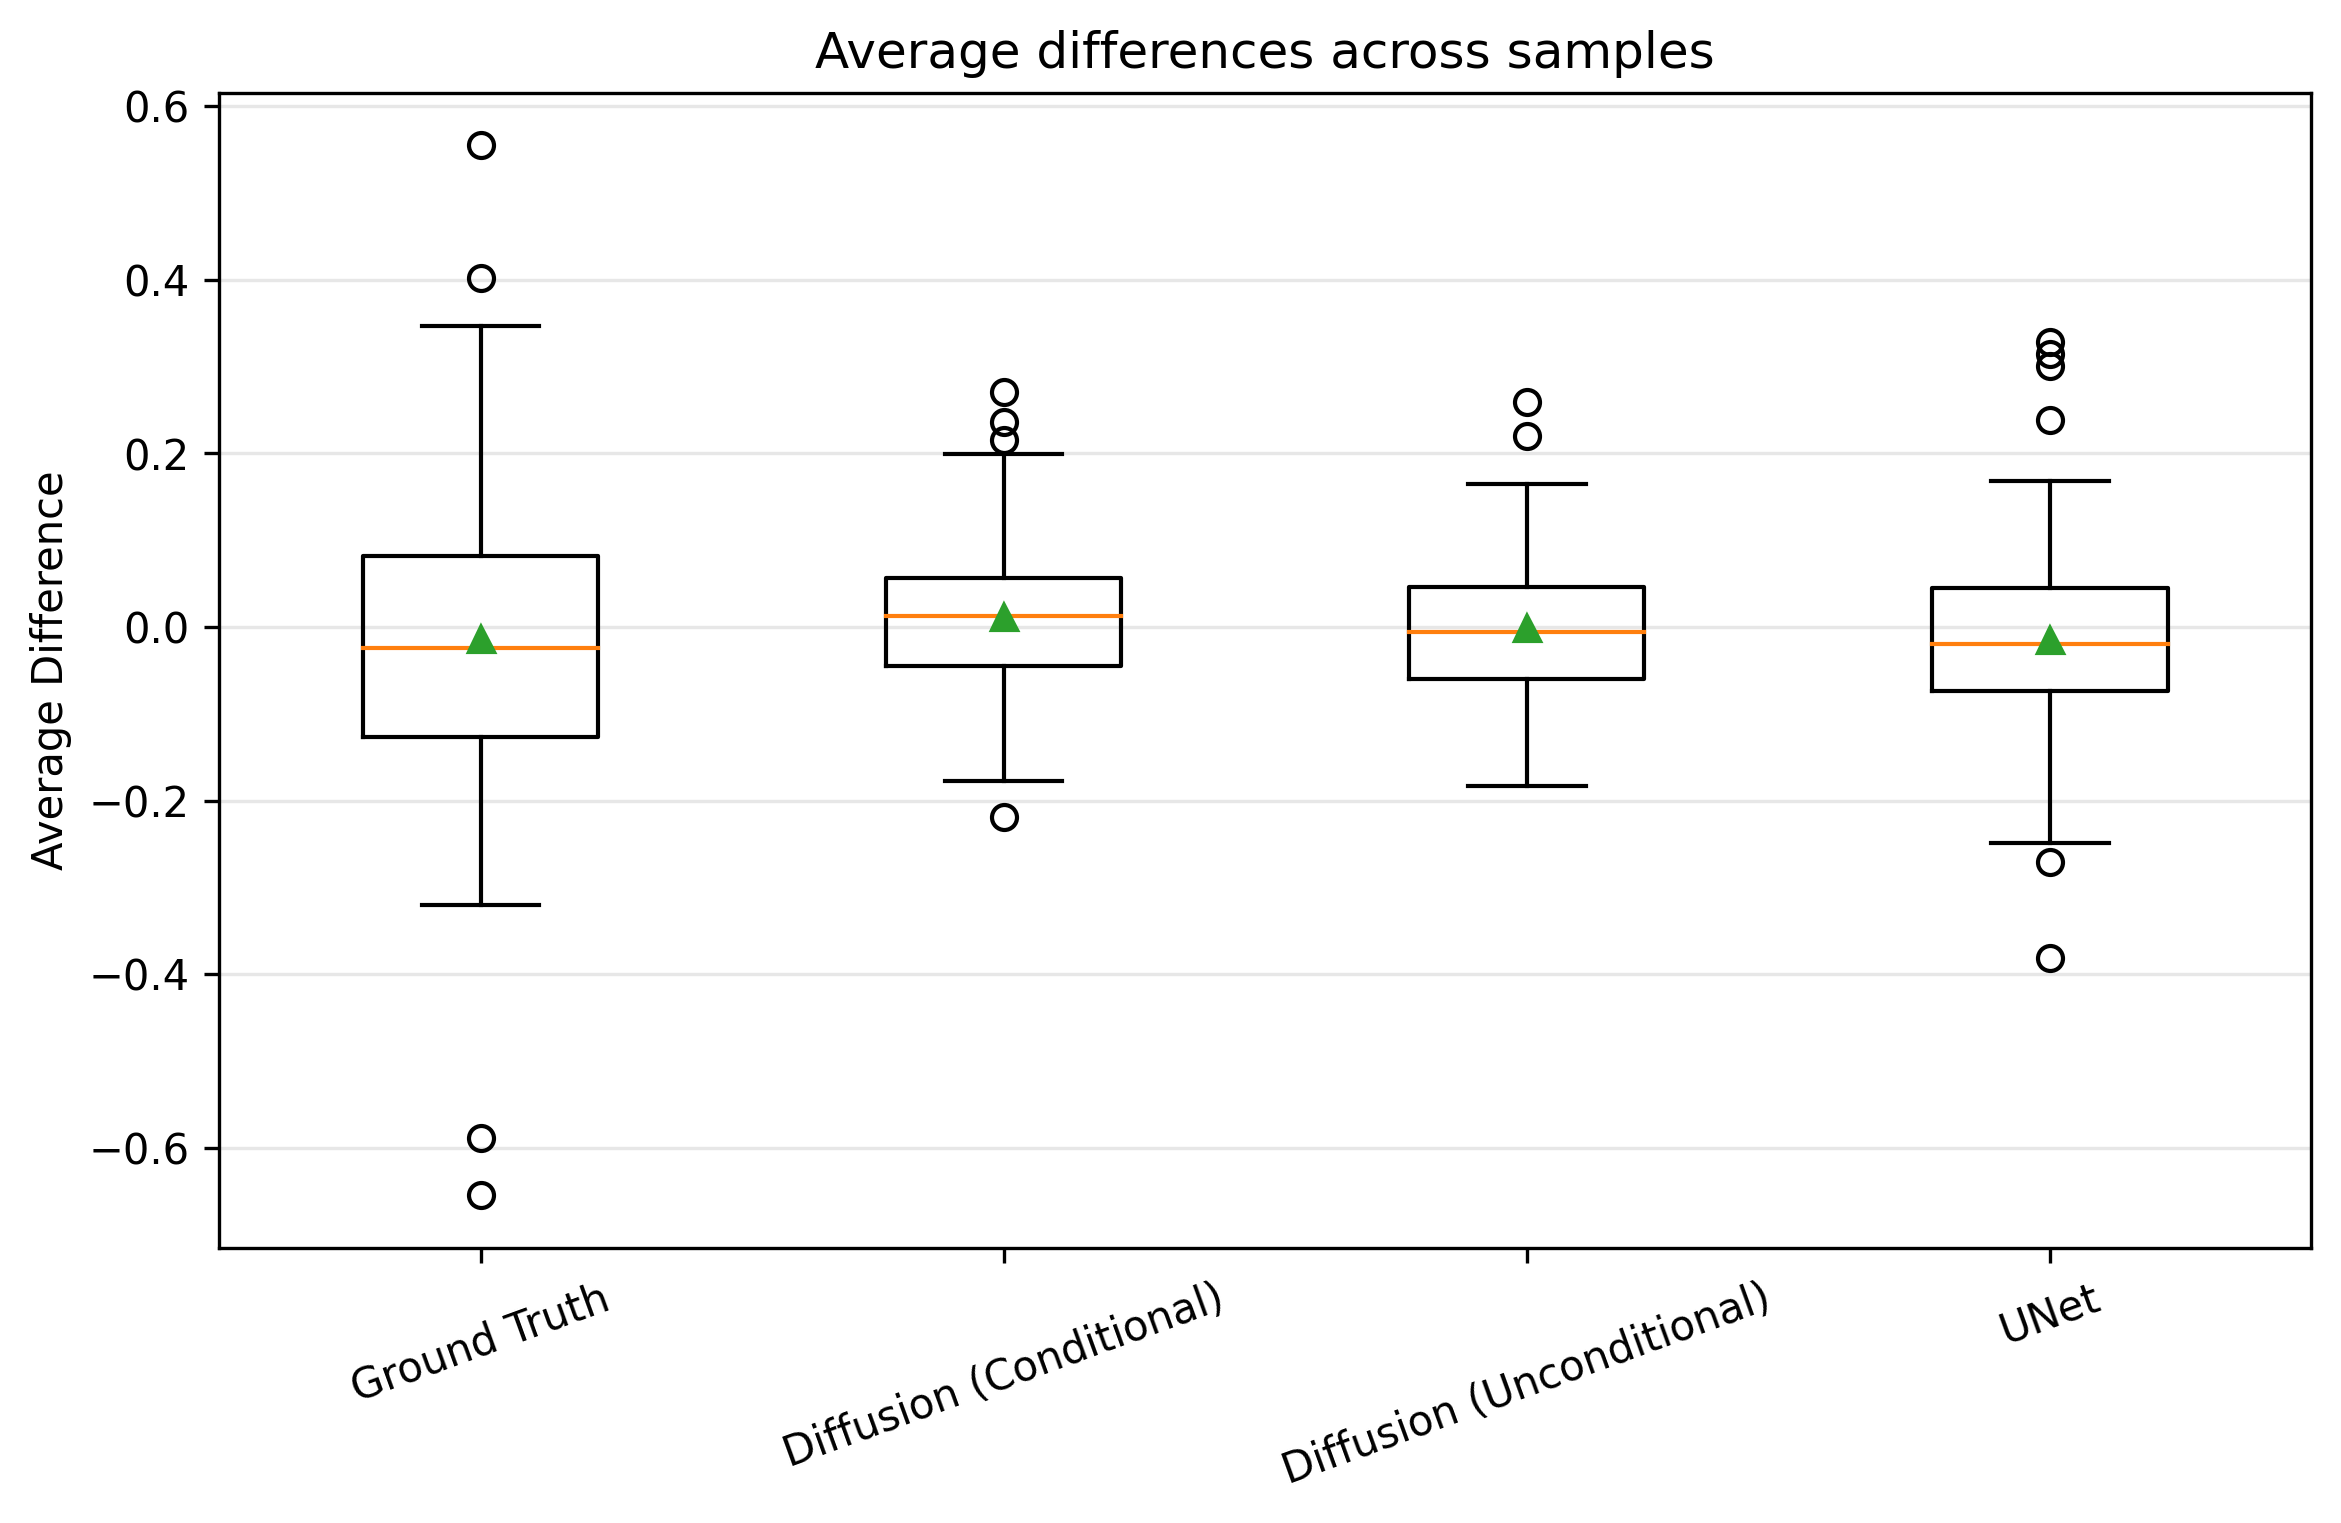

In [49]:
labels = ['Ground Truth', 'Diffusion (Conditional)', 'Diffusion (Unconditional)', 'UNet']

data = [
    np.mean(gt_pct, axis=1),
    np.mean(diff_cond_pct, axis=1),
    np.mean(diff_nocond_pct, axis=1),
    np.mean(unet_pred_pct, axis=1),
]

plt.figure(figsize=(9, 5))

plt.boxplot(data, labels=labels, showmeans=True)

plt.ylabel("Average Difference")
plt.title("Average differences across samples")
plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)

save_path = "/users/framunno/visual_res/plot_boxplot.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

Image.open(save_path)

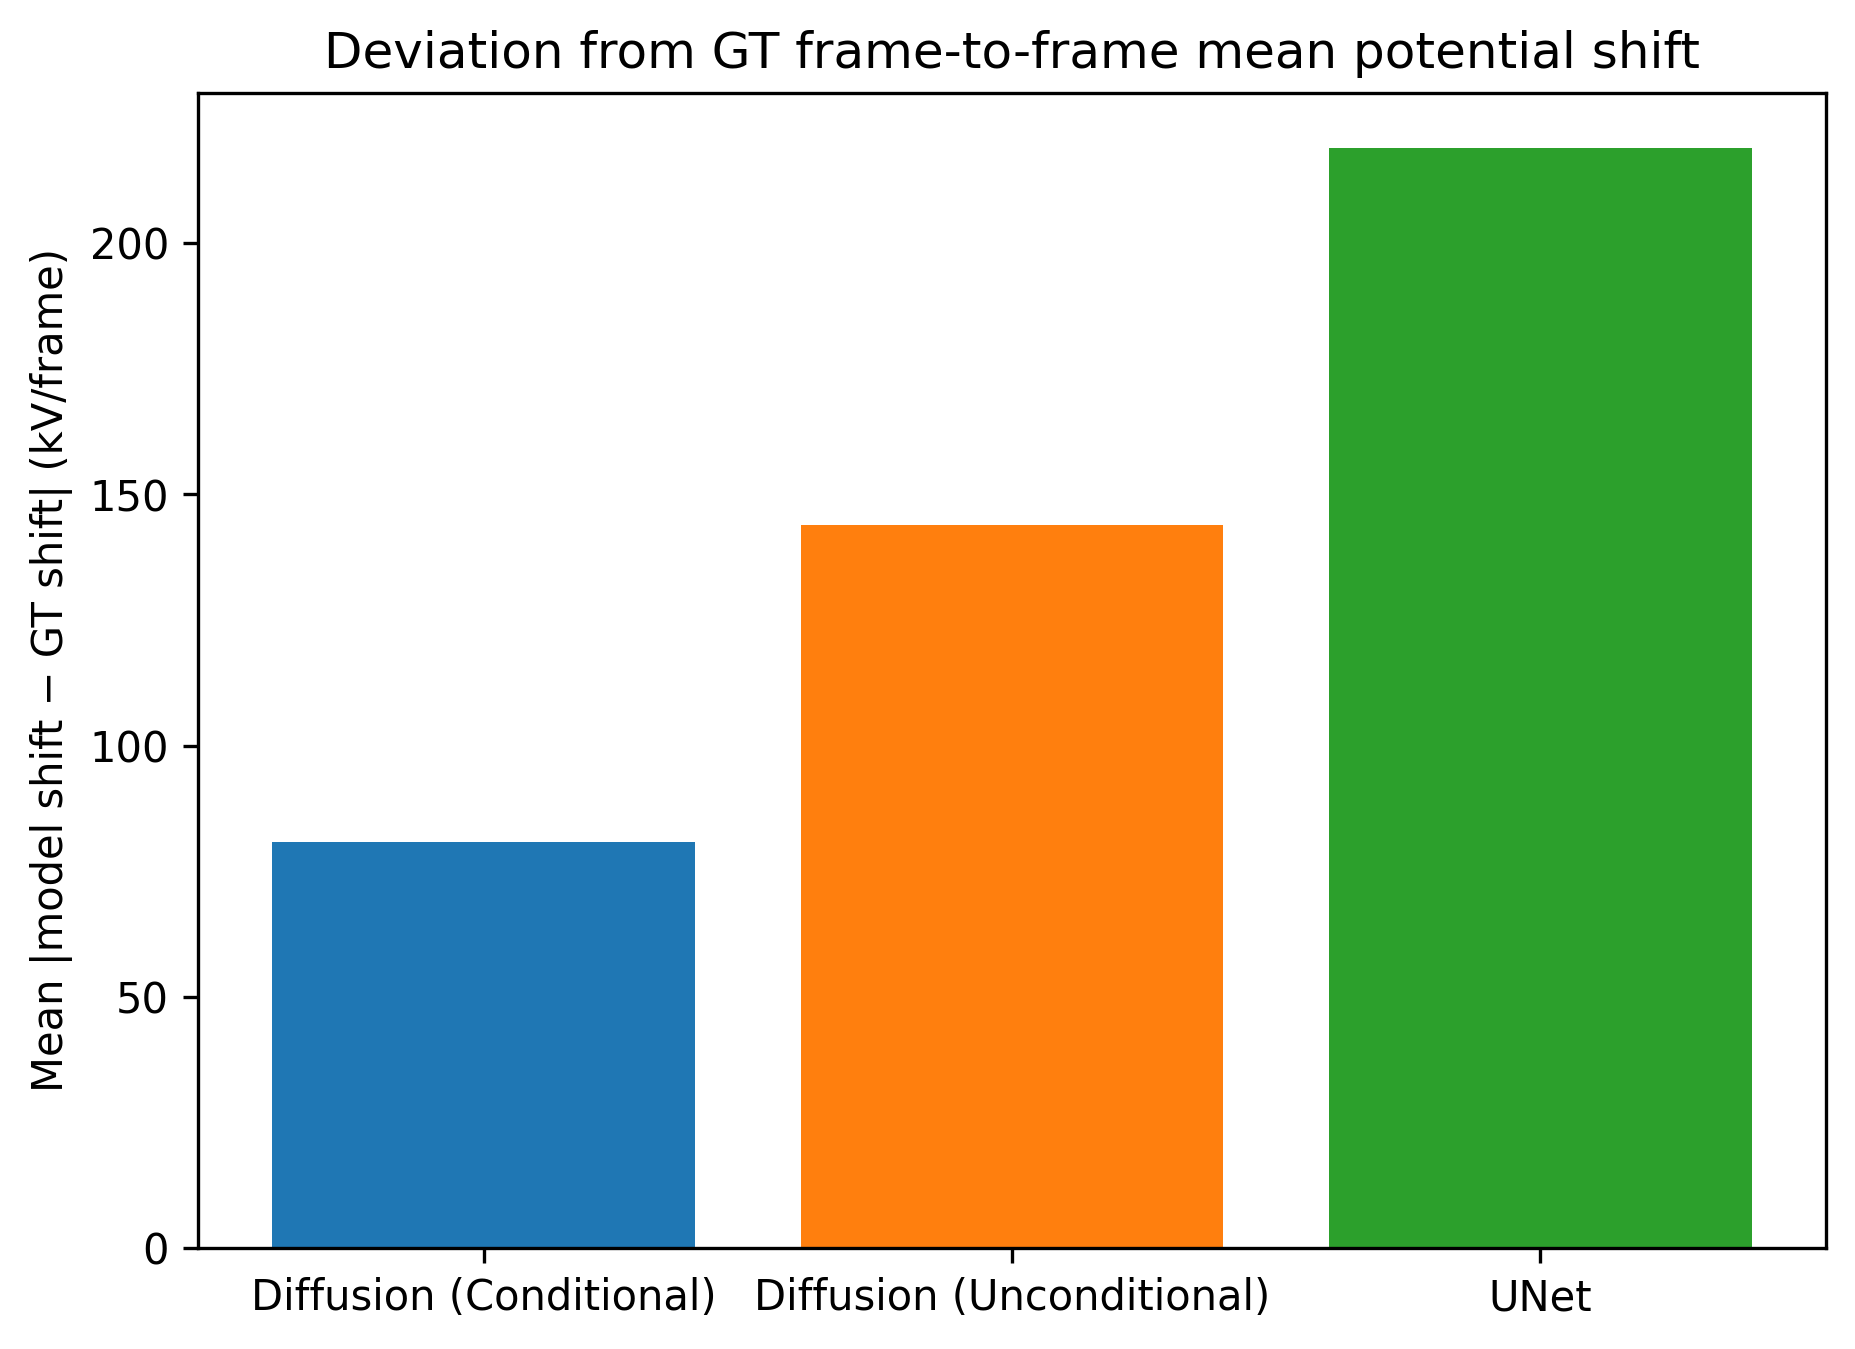

In [52]:
import matplotlib.ticker as mtick

x = ['Diffusion (Conditional)', 'Diffusion (Unconditional)', 'UNet']

vals = [
    np.mean(np.abs(average_time_diff_cond   - average_time_gt)),
    np.mean(np.abs(average_time_diff_nocond - average_time_gt)),
    np.mean(np.abs(average_time_unet        - average_time_gt)),
]

plt.figure(figsize=(7, 5))
plt.bar(x[0], vals[0], alpha=1)
plt.bar(x[1], vals[1], alpha=1)
plt.bar(x[2], vals[2], alpha=1)
plt.ylabel("Mean |model shift − GT shift| (kV/frame)")
plt.title("Deviation from GT frame-to-frame mean potential shift")

save_path = "/users/framunno/visual_res/plot_bar.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.close()

Image.open(save_path)


In [55]:
print(vals)

[np.float64(80.72034157782062), np.float64(143.95232697657548), np.float64(218.9947512196182)]


Median traj std:   2604 V
Median traj range: 9828 V
Sequences with range > 5kV: 94 / 101


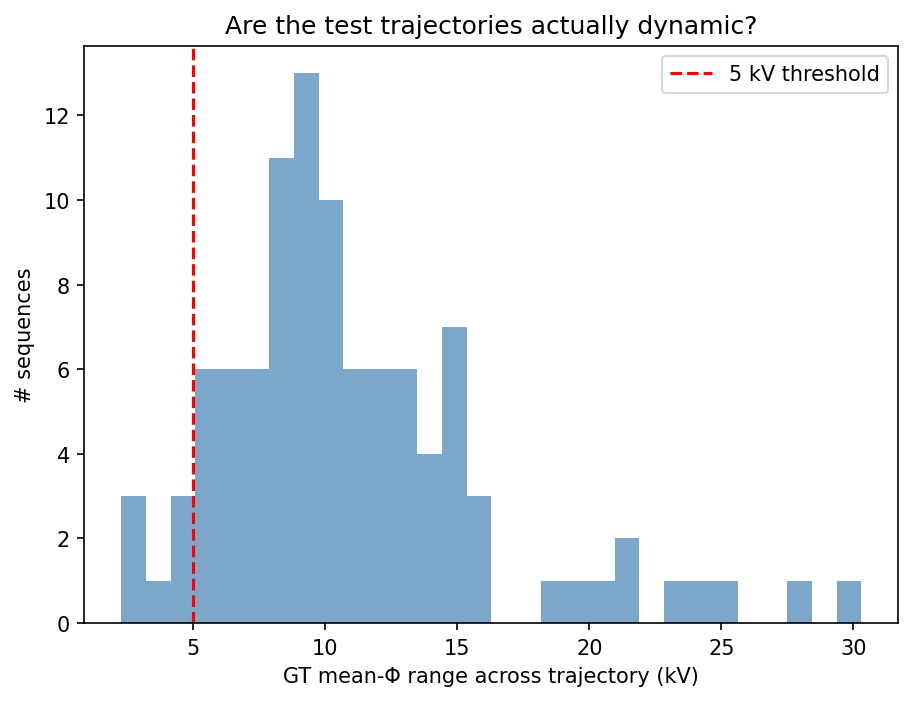

In [53]:
# How much does GT actually vary within each trajectory?
gt_phys_mean_V = np.mean(unnorm_v(gt_images_concat), axis=(-1, -2))  # (101, 35)
traj_std   = gt_phys_mean_V.std(axis=1)
traj_range = np.ptp(gt_phys_mean_V, axis=1)  # max - min across frames

print(f'Median traj std:   {np.median(traj_std):.0f} V')
print(f'Median traj range: {np.median(traj_range):.0f} V')
print(f'Sequences with range > 5kV: {(traj_range > 5000).sum()} / {len(traj_range)}')

plt.figure(figsize=(7, 5))
plt.hist(traj_range / 1000, bins=30, color='steelblue', alpha=0.7)
plt.xlabel('GT mean-Φ range across trajectory (kV)')
plt.ylabel('# sequences')
plt.title('Are the test trajectories actually dynamic?')
plt.axvline(5, color='red', linestyle='--', label='5 kV threshold')
plt.legend()

save_path = '/users/framunno/visual_res/traj_range_hist.png'
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.close()
Image.open(save_path)

In [54]:
# How much does the spatial PATTERN change between consecutive frames?
gt_phys_full = unnorm_v(gt_images_concat)  # (101, 35, H, W)
frame_diffs  = np.abs(np.diff(gt_phys_full, axis=1))  # (101, 34, H, W)
pattern_change = frame_diffs.mean(axis=(-1, -2))       # (101, 34) mean abs pixel change per frame

print(f'Median frame-to-frame pixel change: {np.median(pattern_change):.0f} V')
print(f'Mean across all sequences/frames:   {pattern_change.mean():.0f} V')

Median frame-to-frame pixel change: 1181 V
Mean across all sequences/frames:   1663 V


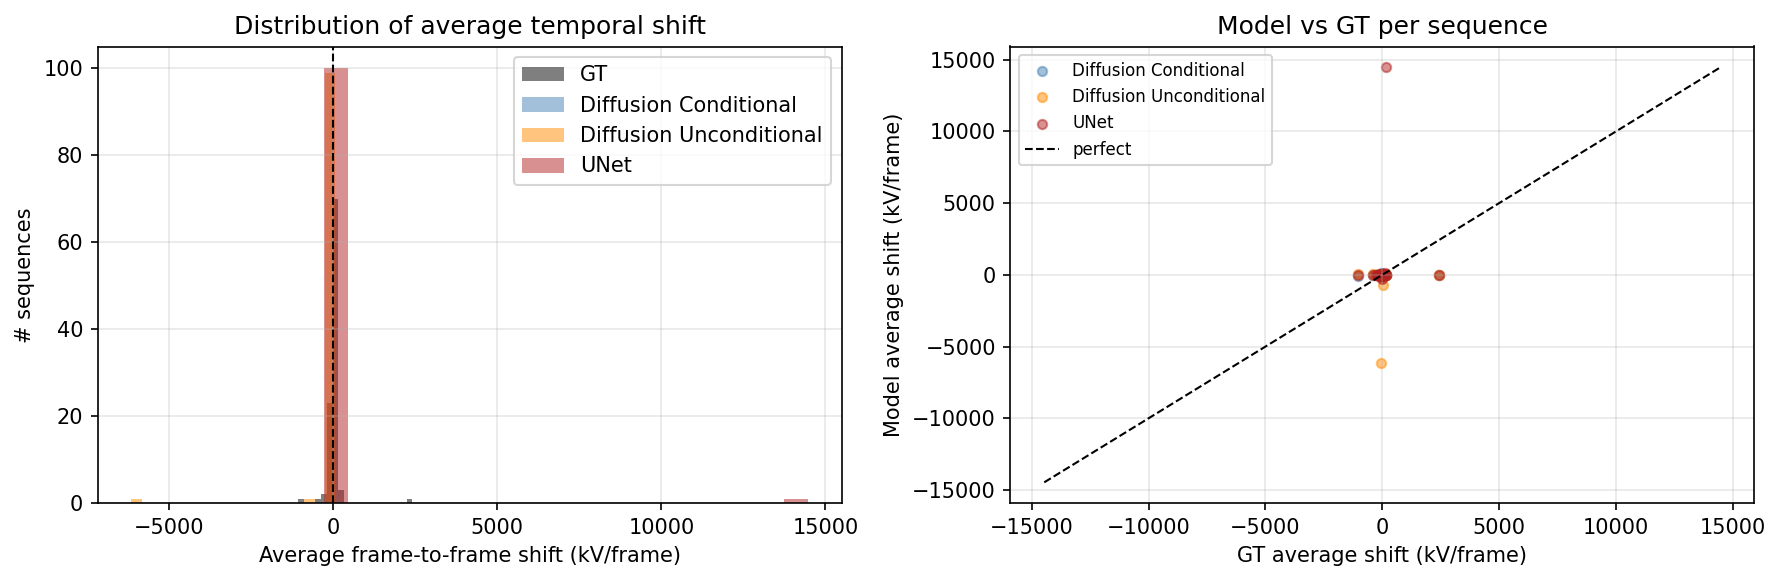

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))                                                                                                                                                      
                                                                                                                                                                                                    
# --- Histogram delle distribuzioni ---                                                                                                                                                              
ax = axes[0]                                                                                                                                                                                         
for arr, label, color in [                                                                                                                                                                         
    (average_time_gt,        'GT',                    'black'),                                                                                                                                      
    (average_time_diff_cond, 'Diffusion Conditional', 'steelblue'),                                                                                                                                  
    (average_time_diff_nocond,'Diffusion Unconditional','darkorange'),                                                                                                                               
    (average_time_unet,      'UNet',                  'firebrick'),                                                                                                                                  
]:                                                                                                                                                                                                   
    ax.hist(arr, bins=20, alpha=0.5, label=label, color=color)                                                                                                                                       
                                                                                                                                                                                                    
ax.axvline(0, color='k', linewidth=1, linestyle='--')                                                                                                                                                
ax.set_xlabel('Average frame-to-frame shift (kV/frame)')
ax.set_ylabel('# sequences')                                                                                                                                                                         
ax.set_title('Distribution of average temporal shift')                                                                                                                                             
ax.legend()                                                                                                                                                                                          
ax.grid(alpha=0.3)                                                                                                                                                                                 
                                                                                                                                                                                                    
# --- Scatter: model shift vs GT shift per sequenza ---                                                                                                                                              
ax2 = axes[1]
for arr, label, color in [                                                                                                                                                                           
    (average_time_diff_cond,  'Diffusion Conditional',  'steelblue'),                                                                                                                              
    (average_time_diff_nocond,'Diffusion Unconditional', 'darkorange'),                                                                                                                              
    (average_time_unet,       'UNet',                   'firebrick'),                                                                                                                                
]:                                                                                                                                                                                                   
    ax2.scatter(average_time_gt, arr, alpha=0.5, label=label, color=color, s=20)                                                                                                                     
                                                                                                                                                                                                    
lim = max(np.abs(average_time_gt).max(), np.abs(average_time_diff_cond).max(),                                                                                                                       
        np.abs(average_time_diff_nocond).max(), np.abs(average_time_unet).max())                                                                                                                   
ax2.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='perfect')                                                                                                                              
ax2.set_xlabel('GT average shift (kV/frame)')                                                                                                                                                        
ax2.set_ylabel('Model average shift (kV/frame)')                                                                                                                                                     
ax2.set_title('Model vs GT per sequence')                                                                                                                                                            
ax2.legend(fontsize=8)                                                                                                                                                                             
ax2.grid(alpha=0.3)                                                                                                                                                                                  
                                                                                                                                                                                                    
plt.tight_layout()                                                                                                                                                                                   
save_path = '/users/framunno/visual_res/shift_distribution.png'                                                                                                                                    
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.close()                                                                                                                                                                                          
Image.open(save_path)